Processando dados para Irece...
  133 setores processados para Irece
Processando dados para Barreiras...
  258 setores processados para Barreiras
Processando dados para Itapuã...
  99 setores processados para Itapuã

Total de setores analisados: 490
Irece: 133 setores
Barreiras: 258 setores
Itapuã: 99 setores


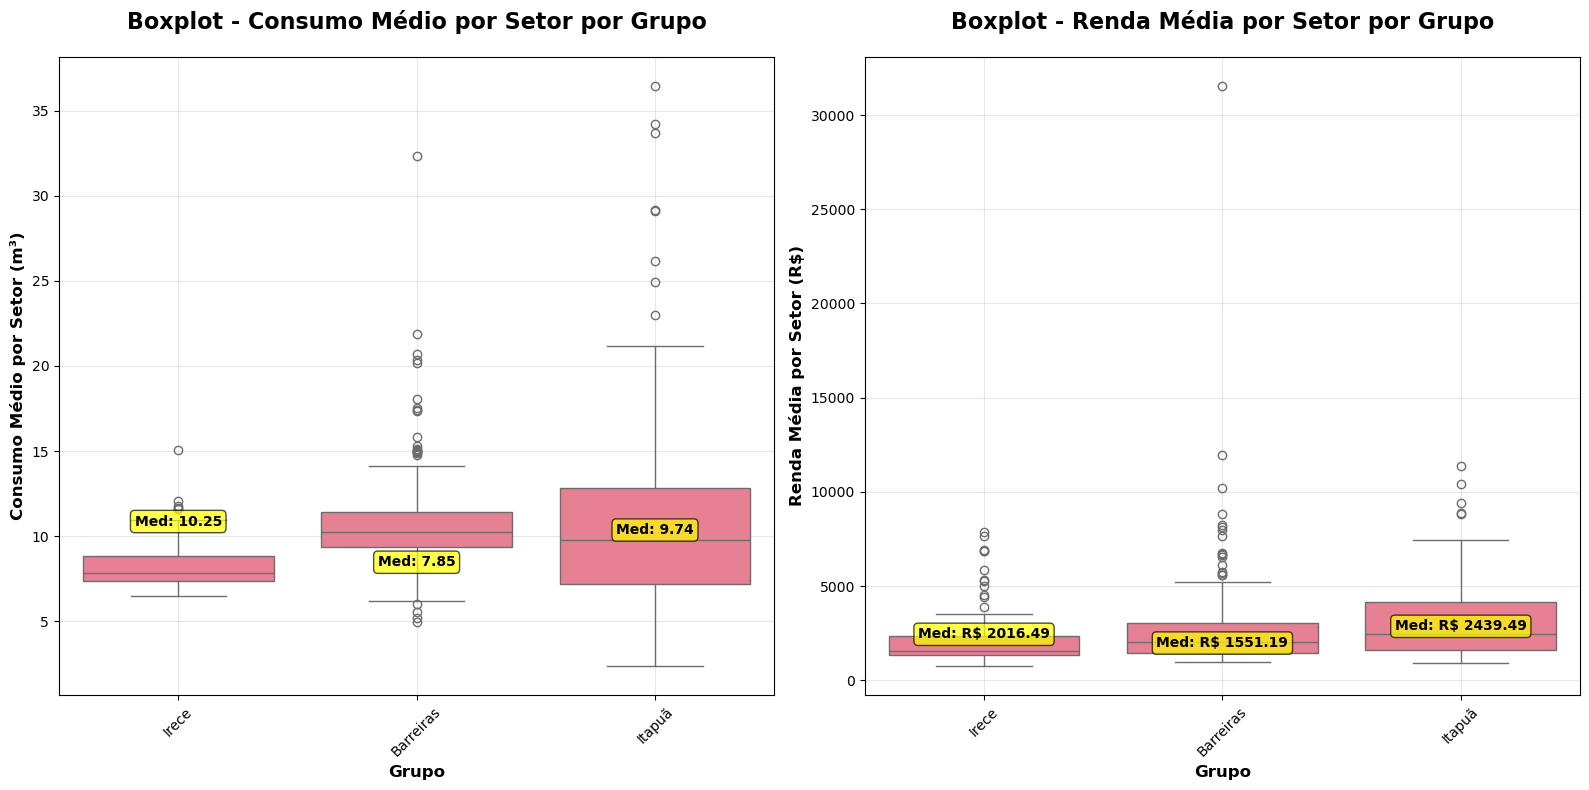


ESTATÍSTICAS DESCRITIVAS - CONSUMO MÉDIO POR SETOR (m³)
           count   mean   std   min   25%    50%    75%    max  median
GRUPO                                                                 
Barreiras  258.0  10.69  2.75  4.94  9.35  10.25  11.44  32.31   10.25
Irece      133.0   8.26  1.34  6.48  7.35   7.85   8.82  15.06    7.85
Itapuã      99.0  11.31  6.79  2.36  7.21   9.74  12.83  36.46    9.74

ESTATÍSTICAS DESCRITIVAS - RENDA MÉDIA POR SETOR (R$)
           count     mean      std     min      25%      50%      75%  \
GRUPO                                                                   
Barreiras  258.0  2661.16  2439.41  953.62  1420.19  2016.50  3054.35   
Irece      133.0  2098.22  1397.61  746.66  1315.69  1551.19  2332.37   
Itapuã      99.0  3187.53  2191.23  904.80  1605.50  2439.49  4163.76   

                max   median  
GRUPO                         
Barreiras  31554.97  2016.50  
Irece       7862.86  1551.19  
Itapuã     11368.08  2439.49  

IDENTIFICAÇ

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)

def converter_renda(valor):
    """Converte valores de renda, tratando 'X' como NaN"""
    if isinstance(valor, str):
        if valor.strip() == 'X':
            return np.nan
        valor = valor.replace('.', '').replace(',', '.')
    try:
        return float(valor)
    except (ValueError, TypeError):
        return np.nan

def processar_dados_grupo(caminho, nome_arquivo_consumidores, nome_arquivo_consumo, nome_grupo):
    """Processa dados para um grupo específico usando CD_SETOR como chave"""
    print(f"Processando dados para {nome_grupo}...")
    
    try:
        # Carregar dados de consumo
        consumo_path = os.path.join(caminho, 'includes', nome_arquivo_consumidores)
        if not os.path.exists(consumo_path):
            print(f"  Arquivo não encontrado: {consumo_path}")
            return pd.DataFrame(columns=['GRUPO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL'])
        
        consumo_df = pd.read_csv(consumo_path, sep=',')
        
        # Carregar dados de consumo médio
        consumo_medio_path = os.path.join(caminho, 'includes', nome_arquivo_consumo)
        if not os.path.exists(consumo_medio_path):
            print(f"  Arquivo não encontrado: {consumo_medio_path}")
            return pd.DataFrame(columns=['GRUPO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL'])
        
        consumo_medio_df = pd.read_csv(consumo_medio_path, sep=';')
        
        # Processar dados de consumo
        consumo_medio_df['AM_REFERENCIA'] = pd.to_datetime(consumo_medio_df['AM_REFERENCIA'], format='%Y%m', errors='coerce')
        consumo_medio_df = consumo_medio_df.dropna(subset=['AM_REFERENCIA'])
        consumo_medio_df = consumo_medio_df.sort_values(by=['SK_MATRICULA', 'AM_REFERENCIA'], ascending=[True, False])
        
        # Calcular média dos últimos 12 meses
        ultimos_12_meses = consumo_medio_df.groupby('SK_MATRICULA').head(12)
        media_consumo = ultimos_12_meses.groupby('SK_MATRICULA')['HCLQTCON'].mean().reset_index()
        media_consumo.rename(columns={'HCLQTCON': 'NN_MEDIA_CONSUMO'}, inplace=True)
        
        # Juntar com dados principais
        consumo_df = pd.merge(consumo_df, media_consumo, on='SK_MATRICULA', how='left')
        
        # Garantir que CD_SETOR é string
        consumo_df['CD_SETOR'] = consumo_df['CD_SETOR'].astype(str)
        
        # Calcular consumo médio por setor (usando CD_SETOR original)
        consumo_por_setor = consumo_df.groupby('CD_SETOR').agg({
            'NN_MEDIA_CONSUMO': 'mean',
            'SK_MATRICULA': 'count'
        }).reset_index()
        
        consumo_por_setor = consumo_por_setor.rename(columns={
            'NN_MEDIA_CONSUMO': 'CONSUMO_MEDIO_SETOR',
            'SK_MATRICULA': 'QTD_CONSUMIDORES'
        })
        
        # Filtrar apenas setores com consumo médio válido
        consumo_por_setor = consumo_por_setor[consumo_por_setor['CONSUMO_MEDIO_SETOR'].notna()]
        consumo_por_setor = consumo_por_setor[consumo_por_setor['CONSUMO_MEDIO_SETOR'] > 0]
        
        # Carregar dados de renda
        renda_path = os.path.join(caminho, 'includes', 'Agregados_por_setores_renda_responsavel_BR.csv')
        if not os.path.exists(renda_path):
            print(f"  Arquivo de renda não encontrado: {renda_path}")
            return pd.DataFrame(columns=['GRUPO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL'])
        
        renda_df = pd.read_csv(renda_path, sep=';')
        
        # Garantir que CD_SETOR é string
        renda_df['CD_SETOR'] = renda_df['CD_SETOR'].astype(str)
        
        renda_df = renda_df.rename(columns={'V06004': 'RENDA_MEDIA_RESPONSAVEL'})
        renda_df['RENDA_MEDIA_RESPONSAVEL'] = renda_df['RENDA_MEDIA_RESPONSAVEL'].apply(converter_renda)
        
        # INNER JOIN com os setores usando CD_SETOR original
        setor_analysis = pd.merge(
            consumo_por_setor,
            renda_df[['CD_SETOR', 'RENDA_MEDIA_RESPONSAVEL']],
            on='CD_SETOR',
            how='inner'
        )
        
        # Remover setores sem dados de renda
        setor_analysis = setor_analysis.dropna(subset=['RENDA_MEDIA_RESPONSAVEL'])
        
        # Filtrar outliers extremos de consumo
        setor_analysis = setor_analysis[setor_analysis['CONSUMO_MEDIO_SETOR'] < 50]
        
        # Adicionar identificador do grupo
        setor_analysis['GRUPO'] = nome_grupo
        
        print(f"  {len(setor_analysis)} setores processados para {nome_grupo}")
        return setor_analysis[['GRUPO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL']]
    
    except Exception as e:
        print(f"  Erro ao processar {nome_grupo}: {str(e)}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame(columns=['GRUPO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL'])

def criar_boxplots(dados_completos):
    """Cria os boxplots para consumo e renda por setor"""
    
    if dados_completos.empty:
        print("Nenhum dado disponível para criar os gráficos.")
        return
    
    # Configurar o layout dos subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. Boxplot para Consumo Médio por Setor
    sns.boxplot(data=dados_completos, x='GRUPO', y='CONSUMO_MEDIO_SETOR', ax=ax1)
    ax1.set_title('Boxplot - Consumo Médio por Setor por Grupo', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Grupo', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Consumo Médio por Setor (m³)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Adicionar valores medianos no gráfico de consumo
    medianas_consumo = dados_completos.groupby('GRUPO')['CONSUMO_MEDIO_SETOR'].median()
    for i, grupo in enumerate(medianas_consumo.index):
        ax1.text(i, medianas_consumo[grupo] + 0.2, f'Med: {medianas_consumo[grupo]:.2f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # 2. Boxplot para Renda Média por Setor
    sns.boxplot(data=dados_completos, x='GRUPO', y='RENDA_MEDIA_RESPONSAVEL', ax=ax2)
    ax2.set_title('Boxplot - Renda Média por Setor por Grupo', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Grupo', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Renda Média por Setor (R$)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Adicionar valores medianos no gráfico de renda
    medianas_renda = dados_completos.groupby('GRUPO')['RENDA_MEDIA_RESPONSAVEL'].median()
    for i, grupo in enumerate(medianas_renda.index):
        ax2.text(i, medianas_renda[grupo] + 50, f'Med: R$ {medianas_renda[grupo]:.2f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('boxplots_consumo_renda_setores.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Estatísticas descritivas
    print("\n" + "="*70)
    print("ESTATÍSTICAS DESCRITIVAS - CONSUMO MÉDIO POR SETOR (m³)")
    print("="*70)
    
    consumo_stats = dados_completos.groupby('GRUPO')['CONSUMO_MEDIO_SETOR'].describe()
    consumo_stats['median'] = dados_completos.groupby('GRUPO')['CONSUMO_MEDIO_SETOR'].median()
    print(consumo_stats.round(2))
    
    print("\n" + "="*70)
    print("ESTATÍSTICAS DESCRITIVAS - RENDA MÉDIA POR SETOR (R$)")
    print("="*70)
    
    renda_stats = dados_completos.groupby('GRUPO')['RENDA_MEDIA_RESPONSAVEL'].describe()
    renda_stats['median'] = dados_completos.groupby('GRUPO')['RENDA_MEDIA_RESPONSAVEL'].median()
    print(renda_stats.round(2))
    
    # Identificar outliers usando o método IQR
    print("\n" + "="*70)
    print("IDENTIFICAÇÃO DE OUTLIERS - MÉTODO IQR")
    print("="*70)
    
    for grupo in dados_completos['GRUPO'].unique():
        grupo_data = dados_completos[dados_completos['GRUPO'] == grupo]
        
        # Outliers para consumo
        Q1_consumo = grupo_data['CONSUMO_MEDIO_SETOR'].quantile(0.25)
        Q3_consumo = grupo_data['CONSUMO_MEDIO_SETOR'].quantile(0.75)
        IQR_consumo = Q3_consumo - Q1_consumo
        outliers_consumo = grupo_data[(grupo_data['CONSUMO_MEDIO_SETOR'] < (Q1_consumo - 1.5 * IQR_consumo)) | 
                                     (grupo_data['CONSUMO_MEDIO_SETOR'] > (Q3_consumo + 1.5 * IQR_consumo))]
        
        # Outliers para renda
        Q1_renda = grupo_data['RENDA_MEDIA_RESPONSAVEL'].quantile(0.25)
        Q3_renda = grupo_data['RENDA_MEDIA_RESPONSAVEL'].quantile(0.75)
        IQR_renda = Q3_renda - Q1_renda
        outliers_renda = grupo_data[(grupo_data['RENDA_MEDIA_RESPONSAVEL'] < (Q1_renda - 1.5 * IQR_renda)) | 
                                   (grupo_data['RENDA_MEDIA_RESPONSAVEL'] > (Q3_renda + 1.5 * IQR_renda))]
        
        print(f"\n{grupo}:")
        print(f"  Outliers de consumo: {len(outliers_consumo)} setores")
        print(f"  Outliers de renda: {len(outliers_renda)} setores")

def main():
    """Função principal"""
    
    # Configurações de caminho para cada grupo
    config_grupos = [
        {
            'caminho': 'C:\\Users\\Edmilson\\Gama_Workspace2\\ABMS-WPI',
            'nome_arquivo_consumidores': 'Tabela_consumidores_Irece_com_setor.csv',
            'nome_arquivo_consumo': 'Tabela_consumo_Irece_120m.csv',
            'nome_grupo': 'Irece'
        },
        {
            'caminho': 'C:\\Users\\Edmilson\\Gama_Workspace2\\ABMS-WPB',
            'nome_arquivo_consumidores': 'Tabela_consumidores_Barreiras_com_setor.csv',
            'nome_arquivo_consumo': 'Tabela_consumo_Barreiras_120m.csv',
            'nome_grupo': 'Barreiras'
        },
        {
            'caminho': 'C:\\Users\\Edmilson\\Gama_Workspace2\\ABMS-WP',
            'nome_arquivo_consumidores': 'Tabela_consumidores_Itapua_com_setor.csv',
            'nome_arquivo_consumo': 'Tabela_consumo_Itapua_60m.csv',
            'nome_grupo': 'Itapuã'
        }
    ]
    
    # Processar dados dos três grupos
    dados_completos = pd.DataFrame()
    
    for config in config_grupos:
        dados_grupo = processar_dados_grupo(
            config['caminho'],
            config['nome_arquivo_consumidores'],
            config['nome_arquivo_consumo'],
            config['nome_grupo']
        )
        dados_completos = pd.concat([dados_completos, dados_grupo], ignore_index=True)
    
    if dados_completos.empty:
        print("Nenhum dado foi processado. Verifique os caminhos dos arquivos.")
        return
    
    print(f"\nTotal de setores analisados: {len(dados_completos)}")
    for grupo in dados_completos['GRUPO'].unique():
        count = len(dados_completos[dados_completos['GRUPO'] == grupo])
        print(f"{grupo}: {count} setores")
    
    # Criar os boxplots
    criar_boxplots(dados_completos)
    
    # Salvar dados consolidados
    dados_completos.to_csv('dados_consolidados_consumo_renda_setores.csv', index=False, sep=';', encoding='utf-8')
    print("\nDados consolidados salvos em: dados_consolidados_consumo_renda_setores.csv")

if __name__ == "__main__":
    main()